COMPLAINT DATA PREPROCESSING PIPELINE
Loading data from /kaggle/input/datase/complaints.csv
Successfully loaded CSV with utf-8 encoding
Dataset loaded with shape: (9609797, 18)

=== Column Identification ===
Dataset columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']
Identified product column: 'Product'
Identified narrative column: 'Issue'

EXPLORATORY DATA ANALYSIS

Dataset Overview:
Total records: 9,609,797
Total columns: 18
Missing values: 32,030,923 (18.52%)

Product Analysis:
Product column: 'Product'
Unique products/services: 21

Top 10 products/services:
  Credit reporting or other personal consumer reports: 4,834,855 (50.3%)
  Credit reporting, credit repair services, or other personal consumer repor

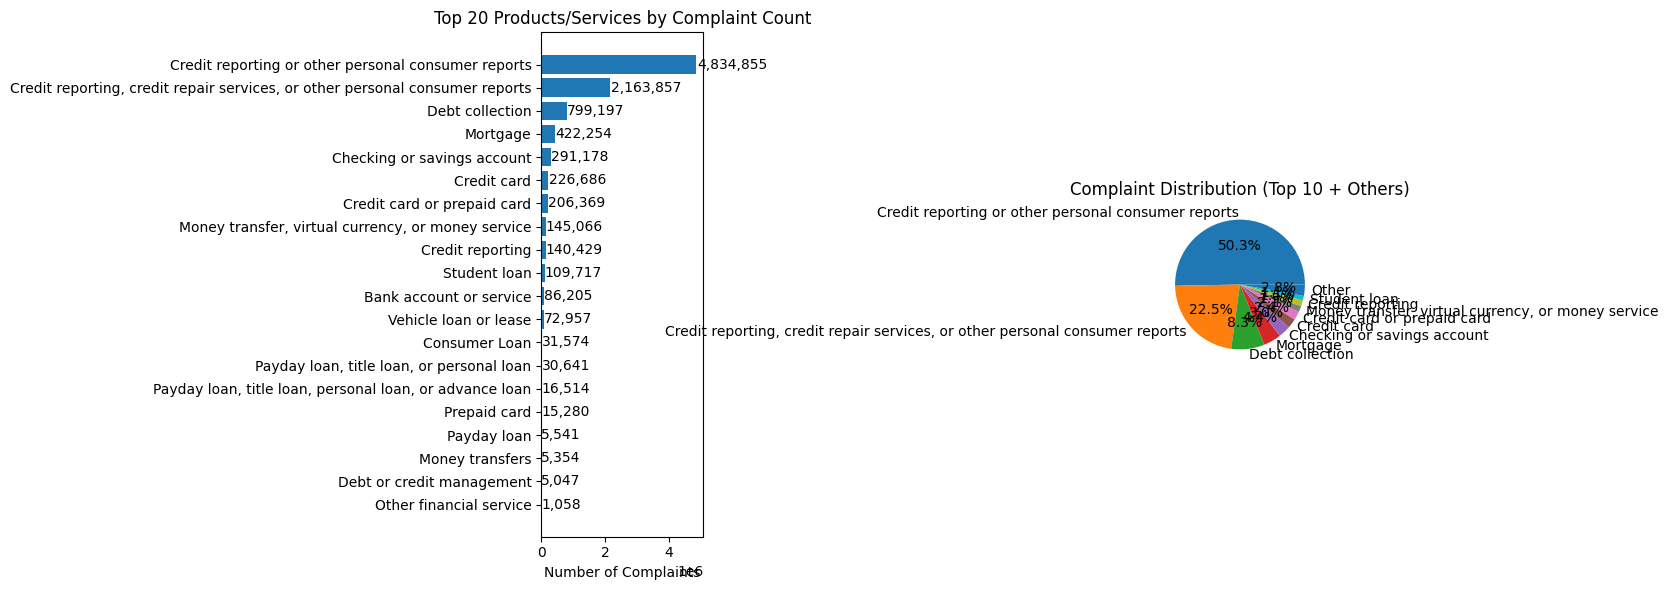


NARRATIVE LENGTH ANALYSIS

Narrative Statistics (in words):
Complaints with narrative: 9,609,791 (100.0%)
Complaints without narrative: 6
Mean length: 5.7 words
Median length: 5.0 words
Standard deviation: 2.1 words
Range: 1 to 16 words
25th percentile: 5.0 words
75th percentile: 6.0 words


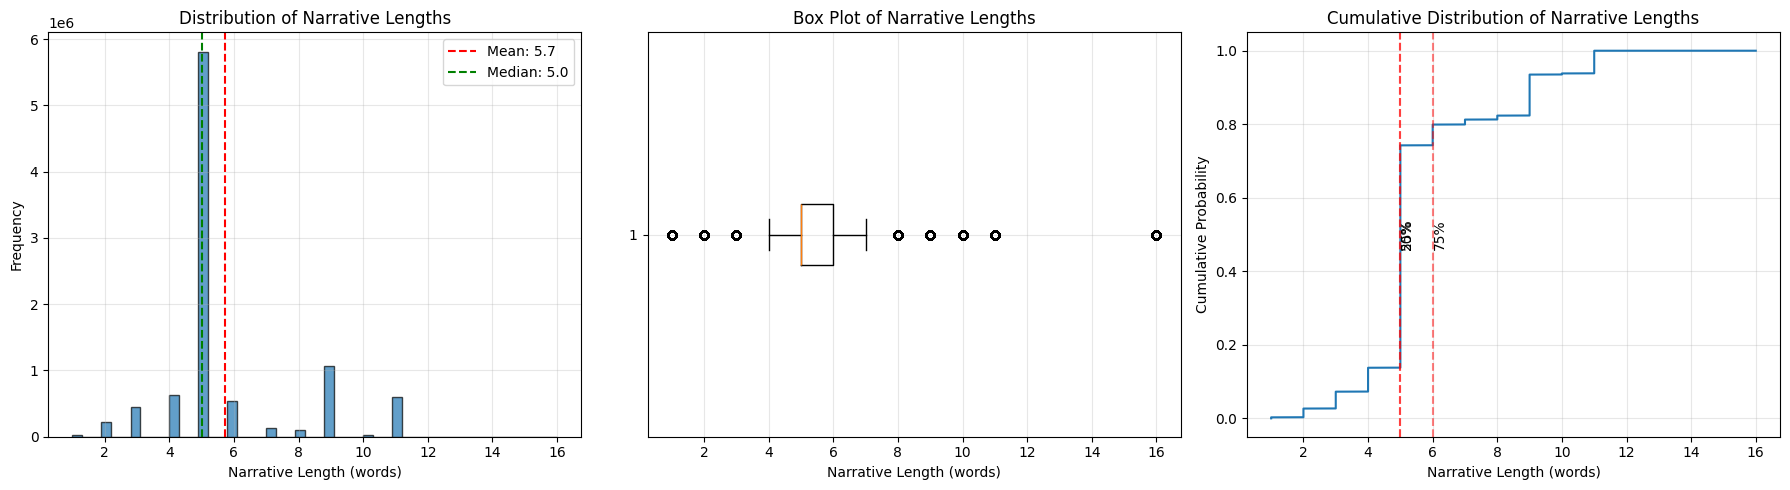


Extreme Length Analysis:
Very short narratives (≤ 10 words): 9,015,728 (93.8%)
Very long narratives (≥ 500 words): 0 (0.0%)

Sample of very short narratives:

1. Length: 5 words
   Preview: Incorrect information on your report...

2. Length: 6 words
   Preview: Attempts to collect debt not owed...

3. Length: 5 words
   Preview: Improper use of your report...

DATASET FILTERING

Starting with 9,609,797 total complaints

1. Filtering for target products/services:
   Target: ['Credit card', 'Personal loan', 'Savings account', 'Money transfers']
   After product filtering: 776,742 complaints (8.1%)

2. Removing empty/invalid narratives:
   After narrative filtering: 717,065 complaints (7.5%)

3. Standardizing product/service names:
   Standardized 6 product/service names

   Final product/service distribution:
   - Credit card: 373,454 complaints (52.1%)
   - Savings account: 291,173 complaints (40.6%)
   - Personal loan: 47,084 complaints (6.6%)
   - Money transfers: 5,354 complaints (0

/kaggle/working/filtered_complaints.csv

In [1]:
# Import required libraries
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import nltk
from typing import Dict

warnings.filterwarnings('ignore')

# Download NLTK resources silently
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

class ComplaintDataPreprocessor:
    """Class for preprocessing complaint ticket data"""
    
    def __init__(self, data_path: str = None):
        self.data_path = data_path or '/kaggle/input/datase/complaints.csv'
        self.df = None
        self.filtered_df = None
        self.target_products = [
            'Credit card', 
            'Personal loan', 
            'Savings account', 
            'Money transfers'
        ]
        self.product_column = None
        self.narrative_column = None

    def _identify_columns(self):
        if self.df is None:
            return
            
        print("\n=== Column Identification ===")
        print(f"Dataset columns: {list(self.df.columns)}")
        
        product_keywords = ['product', 'service', 'category', 'type', 'department']
        narrative_keywords = ['description', 'narrative', 'complaint', 'issue', 'details', 'comment', 'text']
        
        for col in self.df.columns:
            col_lower = col.lower()
            if any(keyword in col_lower for keyword in product_keywords):
                if self.product_column is None:
                    self.product_column = col
                    print(f"Identified product column: '{col}'")
            if any(keyword in col_lower for keyword in narrative_keywords):
                if self.df[col].dtype == 'object' and self.df[col].notna().any():
                    if self.narrative_column is None:
                        self.narrative_column = col
                        print(f"Identified narrative column: '{col}'")
        
        if self.product_column is None:
            for col in self.df.columns:
                if self.df[col].dtype == 'object' and self.df[col].nunique() < 100:
                    self.product_column = col
                    print(f"Guessed product column: '{col}' (low cardinality text)")
                    break
        
        if self.narrative_column is None:
            for col in self.df.columns:
                if self.df[col].dtype == 'object':
                    avg_len = self.df[col].astype(str).str.len().mean()
                    if avg_len > 50:
                        self.narrative_column = col
                        print(f"Guessed narrative column: '{col}' (average length: {avg_len:.0f} chars)")
                        break

    def load_data(self) -> pd.DataFrame:
        print(f"Loading data from {self.data_path}")
        if not os.path.exists(self.data_path):
            print(f"Error: File not found at {self.data_path}")
            print("Please upload the dataset to Kaggle and adjust the path.")
            return None
        
        encodings = ['utf-8', 'latin-1', 'ISO-8859-1', 'cp1252']
        for encoding in encodings:
            try:
                self.df = pd.read_csv(self.data_path, encoding=encoding, low_memory=False, on_bad_lines='skip')
                print(f"Successfully loaded CSV with {encoding} encoding")
                break
            except (UnicodeDecodeError, Exception):
                try:
                    self.df = pd.read_csv(self.data_path, encoding=encoding, sep=';', low_memory=False, on_bad_lines='skip')
                    break
                except:
                    try:
                        self.df = pd.read_csv(self.data_path, encoding=encoding, sep='\t', low_memory=False, on_bad_lines='skip')
                        break
                    except:
                        continue
        
        if self.df is None:
            print("Failed to load the file.")
            return None
        
        print(f"Dataset loaded with shape: {self.df.shape}")
        self._identify_columns()
        return self.df

    def perform_initial_eda(self) -> Dict:
        if self.df is None:
            raise ValueError("Data not loaded. Call load_data() first.")
        
        eda_stats = {}
        eda_stats['total_records'] = len(self.df)
        eda_stats['total_columns'] = len(self.df.columns)
        eda_stats['missing_values'] = self.df.isnull().sum().sum()
        eda_stats['missing_percentage'] = (eda_stats['missing_values'] / (self.df.shape[0] * self.df.shape[1])) * 100
        eda_stats['data_types'] = self.df.dtypes.value_counts().to_dict()
        
        if self.product_column:
            eda_stats['unique_products'] = self.df[self.product_column].nunique()
            eda_stats['top_products'] = self.df[self.product_column].value_counts().head(10).to_dict()
        if self.narrative_column:
            non_empty = self.df[self.narrative_column].notna() & (self.df[self.narrative_column].astype(str).str.strip() != '')
            eda_stats['non_empty_narratives'] = non_empty.sum()
            eda_stats['empty_narratives'] = len(self.df) - non_empty.sum()
        
        print("\n" + "="*60)
        print("EXPLORATORY DATA ANALYSIS")
        print("="*60)
        print(f"\nDataset Overview:")
        print(f"Total records: {eda_stats['total_records']:,}")
        print(f"Total columns: {eda_stats['total_columns']}")
        print(f"Missing values: {eda_stats['missing_values']:,} ({eda_stats['missing_percentage']:.2f}%)")
        
        if self.product_column:
            print(f"\nProduct Analysis:")
            print(f"Product column: '{self.product_column}'")
            print(f"Unique products/services: {eda_stats['unique_products']}")
            print(f"\nTop 10 products/services:")
            for product, count in eda_stats['top_products'].items():
                print(f"  {product}: {count:,} ({count/len(self.df)*100:.1f}%)")
        if self.narrative_column:
            print(f"\nNarrative Analysis:")
            print(f"Narrative column: '{self.narrative_column}'")
            print(f"Non-empty narratives: {eda_stats['non_empty_narratives']:,} ({eda_stats['non_empty_narratives']/len(self.df)*100:.1f}%)")
            print(f"Empty narratives: {eda_stats['empty_narratives']:,} ({eda_stats['empty_narratives']/len(self.df)*100:.1f}%)")
        return eda_stats

    def analyze_product_distribution(self):
        if self.df is None or self.product_column is None:
            print("No product data available for analysis")
            return None
        
        print("\n" + "="*60)
        print("PRODUCT/SERVICE DISTRIBUTION ANALYSIS")
        print("="*60)
        product_dist = self.df[self.product_column].value_counts()
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        top_n = min(20, len(product_dist))
        top_products = product_dist.head(top_n)
        axes[0].barh(range(len(top_products)), top_products.values)
        axes[0].set_yticks(range(len(top_products)))
        axes[0].set_yticklabels(top_products.index)
        axes[0].set_xlabel('Number of Complaints')
        axes[0].set_title(f'Top {top_n} Products/Services by Complaint Count')
        axes[0].invert_yaxis()
        for i, (bar, value) in enumerate(zip(axes[0].patches, top_products.values)):
            axes[0].text(value + max(value * 0.01, 1), i, f'{value:,}', va='center')
        top_10 = product_dist.head(10)
        other = product_dist[10:].sum() if len(product_dist) > 10 else 0
        if other > 0:
            top_10 = pd.concat([top_10, pd.Series({'Other': other})])
        axes[1].pie(top_10.values, labels=top_10.index, autopct='%1.1f%%')
        axes[1].set_title('Complaint Distribution (Top 10 + Others)')
        plt.tight_layout()
        # Save directly to /kaggle/working/ (no subfolders)
        plt.savefig('/kaggle/working/product_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        return product_dist

    def analyze_narrative_lengths(self) -> Dict:
        if self.df is None or self.narrative_column is None:
            print("No narrative data available for analysis")
            return None
        
        def count_words(text):
            if pd.isna(text):
                return 0
            text_str = str(text).strip()
            if text_str == '' or text_str.lower() in ['nan', 'null', 'none', 'na']:
                return 0
            return len(text_str.split())
        
        self.df['narrative_length_words'] = self.df[self.narrative_column].apply(count_words)
        valid_narratives = self.df[self.df['narrative_length_words'] > 0]
        length_stats = {
            'total_with_narrative': len(valid_narratives),
            'total_without_narrative': len(self.df) - len(valid_narratives),
            'percent_with_narrative': (len(valid_narratives) / len(self.df)) * 100,
            'mean_length': valid_narratives['narrative_length_words'].mean(),
            'median_length': valid_narratives['narrative_length_words'].median(),
            'std_length': valid_narratives['narrative_length_words'].std(),
            'min_length': valid_narratives['narrative_length_words'].min(),
            'max_length': valid_narratives['narrative_length_words'].max(),
            'q1': valid_narratives['narrative_length_words'].quantile(0.25),
            'q3': valid_narratives['narrative_length_words'].quantile(0.75)
        }
        print("\n" + "="*60)
        print("NARRATIVE LENGTH ANALYSIS")
        print("="*60)
        print(f"\nNarrative Statistics (in words):")
        print(f"Complaints with narrative: {length_stats['total_with_narrative']:,} ({length_stats['percent_with_narrative']:.1f}%)")
        print(f"Complaints without narrative: {length_stats['total_without_narrative']:,}")
        print(f"Mean length: {length_stats['mean_length']:.1f} words")
        print(f"Median length: {length_stats['median_length']:.1f} words")
        print(f"Standard deviation: {length_stats['std_length']:.1f} words")
        print(f"Range: {length_stats['min_length']} to {length_stats['max_length']} words")
        print(f"25th percentile: {length_stats['q1']:.1f} words")
        print(f"75th percentile: {length_stats['q3']:.1f} words")
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].hist(valid_narratives['narrative_length_words'], bins=50, edgecolor='black', alpha=0.7)
        axes[0].axvline(length_stats['mean_length'], color='red', linestyle='--', label=f'Mean: {length_stats["mean_length"]:.1f}')
        axes[0].axvline(length_stats['median_length'], color='green', linestyle='--', label=f'Median: {length_stats["median_length"]:.1f}')
        axes[0].set_xlabel('Narrative Length (words)')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('Distribution of Narrative Lengths')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[1].boxplot(valid_narratives['narrative_length_words'], vert=False)
        axes[1].set_xlabel('Narrative Length (words)')
        axes[1].set_title('Box Plot of Narrative Lengths')
        axes[1].grid(True, alpha=0.3)
        sorted_lengths = np.sort(valid_narratives['narrative_length_words'])
        cum_dist = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
        axes[2].plot(sorted_lengths, cum_dist)
        axes[2].set_xlabel('Narrative Length (words)')
        axes[2].set_ylabel('Cumulative Probability')
        axes[2].set_title('Cumulative Distribution of Narrative Lengths')
        axes[2].grid(True, alpha=0.3)
        for percentile, value in [(25, length_stats['q1']), (50, length_stats['median_length']), (75, length_stats['q3'])]:
            axes[2].axvline(value, color='red', linestyle='--', alpha=0.5)
            axes[2].text(value, 0.5, f'{percentile}%', rotation=90, va='center')
        plt.tight_layout()
        plt.savefig('/kaggle/working/narrative_length_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        short_threshold = 10
        long_threshold = 500
        very_short = valid_narratives[valid_narratives['narrative_length_words'] <= short_threshold]
        very_long = valid_narratives[valid_narratives['narrative_length_words'] >= long_threshold]
        print(f"\nExtreme Length Analysis:")
        print(f"Very short narratives (≤ {short_threshold} words): {len(very_short):,} ({len(very_short)/len(valid_narratives)*100:.1f}%)")
        print(f"Very long narratives (≥ {long_threshold} words): {len(very_long):,} ({len(very_long)/len(valid_narratives)*100:.1f}%)")
        if len(very_short) > 0:
            print(f"\nSample of very short narratives:")
            for i, (idx, row) in enumerate(very_short.head(3).iterrows()):
                print(f"\n{i+1}. Length: {row['narrative_length_words']} words")
                narrative_preview = str(row[self.narrative_column])[:150]
                print(f"   Preview: {narrative_preview}...")
        length_stats['very_short_count'] = len(very_short)
        length_stats['very_long_count'] = len(very_long)
        return length_stats

    def filter_dataset(self) -> pd.DataFrame:
        if self.df is None:
            raise ValueError("Data not loaded. Call load_data() first.")
        
        print("\n" + "="*60)
        print("DATASET FILTERING")
        print("="*60)
        filtered_df = self.df.copy()
        original_count = len(filtered_df)
        print(f"\nStarting with {original_count:,} total complaints")
        
        if self.product_column:
            print(f"\n1. Filtering for target products/services:")
            print(f"   Target: {self.target_products}")
            product_patterns = []
            for product in self.target_products:
                patterns = [product.lower(), product.replace(' ', '').lower(), product.replace(' ', '-').lower()]
                product_patterns.extend(patterns)
            product_mask = filtered_df[self.product_column].astype(str).str.lower().apply(
                lambda x: any(pattern in x for pattern in product_patterns)
            )
            filtered_df = filtered_df[product_mask].copy()
            print(f"   After product filtering: {len(filtered_df):,} complaints ({len(filtered_df)/original_count*100:.1f}%)")
        
        if self.narrative_column:
            print(f"\n2. Removing empty/invalid narratives:")
            def is_valid_narrative(text):
                if pd.isna(text):
                    return False
                text_str = str(text).strip()
                if text_str == '':
                    return False
                if text_str.lower() in ['nan', 'null', 'none', 'na', 'n/a', 'not provided', 'no description']:
                    return False
                words = text_str.split()
                if len(words) < 3:
                    return False
                if not any(char.isalnum() for char in text_str):
                    return False
                return True
            
            narrative_mask = filtered_df[self.narrative_column].apply(is_valid_narrative)
            filtered_df = filtered_df[narrative_mask].copy()
            print(f"   After narrative filtering: {len(filtered_df):,} complaints ({len(filtered_df)/original_count*100:.1f}%)")
        
        if self.product_column and len(filtered_df) > 0:
            print(f"\n3. Standardizing product/service names:")
            product_mapping = {}
            for target in self.target_products:
                target_lower = target.lower()
                variations = filtered_df[
                    filtered_df[self.product_column].astype(str).str.lower().str.contains(target_lower, na=False)
                ][self.product_column].dropna().unique()
                for var in variations:
                    product_mapping[var] = target
            if product_mapping:
                filtered_df[self.product_column] = filtered_df[self.product_column].map(product_mapping).fillna(filtered_df[self.product_column])
                print(f"   Standardized {len(product_mapping)} product/service names")
            print(f"\n   Final product/service distribution:")
            final_dist = filtered_df[self.product_column].value_counts()
            for product, count in final_dist.items():
                print(f"   - {product}: {count:,} complaints ({count/len(filtered_df)*100:.1f}%)")
        
        self.filtered_df = filtered_df
        print(f"\nFiltering complete! Final dataset: {len(filtered_df):,} complaints")
        return filtered_df

    def clean_text_narratives(self) -> pd.DataFrame:
        if self.filtered_df is None:
            raise ValueError("Filtered data not available. Call filter_dataset() first.")
        if self.narrative_column is None:
            print("No narrative column to clean")
            return self.filtered_df
        
        print("\n" + "="*60)
        print("TEXT CLEANING")
        print("="*60)
        cleaned_df = self.filtered_df.copy()
        cleaned_col = 'cleaned_narrative'
        
        def clean_text(text):
            if pd.isna(text):
                return ""
            text_str = str(text).lower()
            boilerplate_patterns = [
                r'^dear (sir|madam|team|support|customer service)',
                r'^to whom it may concern', r'^hi,?\s*', r'^hello,?\s*',
                r'^i am writing (to|because|regarding|about)',
                r'^this is (regarding|about|to report|to inform)',
                r'^i would like to (report|complain|inform|notify)',
                r'^please be (advised|informed|noted)', r'^kindly (note|be informed|be advised)',
                r'^regarding (my|our|the)', r'^reference:?.*$', r'^case (id|number|no):?.*$',
                r'^ticket (id|number|no):?.*$', r'^issue (id|number|no):?.*$',
                r'^complaint (id|number|no):?.*$', r'^incident (id|number|no):?.*$',
                r'^date:? \d{1,2}[/\-]\d{1,2}[/\-]\d{2,4}',
                r'^time:? \d{1,2}:\d{2}', r'^account (id|number|no):?[\s\w\*]+',
                r'^customer (id|number|no):?[\s\w\*]+', r'^phone:?[\s\d\-\(\)]+',
                r'^email:?[\s\w\.\-@]+', r'^address:?[\s\w\.,\-]+',
                r'\bthank you\b.*$', r'\bbest regards\b.*$', r'\bsincerely\b.*$',
                r'\bplease help\b.*$', r'\blooking forward to your (response|reply)\b.*$',
                r'xxxx', r'\*{4,}', r'\[.*?\]', r'\(.*?\)',
            ]
            for pattern in boilerplate_patterns:
                text_str = re.sub(pattern, '', text_str, flags=re.IGNORECASE | re.MULTILINE)
            text_str = re.sub(r'https?://\S+|www\.\S+', '', text_str)
            text_str = re.sub(r'\S+@\S+', '', text_str)
            text_str = re.sub(r'[^\w\s.,!?;:\-\'"()]', ' ', text_str)
            text_str = re.sub(r'\s+', ' ', text_str).strip()
            sentences = re.split(r'[.!?]+', text_str)
            valid_sentences = []
            for sentence in sentences:
                sentence = sentence.strip()
                if len(sentence.split()) >= 3:
                    valid_sentences.append(sentence)
            text_str = '. '.join(valid_sentences)
            return text_str
        
        print("Cleaning narratives...")
        cleaned_df[cleaned_col] = cleaned_df[self.narrative_column].apply(clean_text)
        def count_original_words(text): return 0 if pd.isna(text) else len(str(text).split())
        def count_cleaned_words(text): return 0 if pd.isna(text) or text == "" else len(text.split())
        original_lengths = cleaned_df[self.narrative_column].apply(count_original_words)
        cleaned_lengths = cleaned_df[cleaned_col].apply(count_cleaned_words)
        print(f"\nCleaning Statistics:")
        print(f"Average original length: {original_lengths.mean():.1f} words")
        print(f"Average cleaned length: {cleaned_lengths.mean():.1f} words")
        reduction_pct = ((original_lengths - cleaned_lengths) / original_lengths.replace(0, 1) * 100).mean()
        print(f"Average reduction: {reduction_pct:.1f}%")
        print(f"\nSample Cleaning Results:")
        for i, idx in enumerate(cleaned_df.head(3).index):
            original = str(cleaned_df.loc[idx, self.narrative_column])
            cleaned = str(cleaned_df.loc[idx, cleaned_col])
            print(f"\n{'='*50}\nSAMPLE {i+1}:\n{'='*50}")
            print(f"\nORIGINAL (first 200 chars):\n{original[:200]}...")
            print(f"\nCLEANED (first 200 chars):\n{cleaned[:200]}...")
            print(f"\nOriginal length: {len(original):,} chars, {len(original.split())} words")
            print(f"Cleaned length: {len(cleaned):,} chars, {len(cleaned.split())} words")
        self.filtered_df = cleaned_df
        empty_cleaned = cleaned_df[cleaned_col].apply(lambda x: x == "").sum()
        if empty_cleaned > 0:
            print(f"\nWarning: {empty_cleaned} narratives became empty after cleaning")
        return cleaned_df

    # ✅ FIXED: Save directly to /kaggle/working/ (visible in output)
    def save_filtered_data(self, output_path: str = '/kaggle/working/filtered_complaints.csv'):
        if self.filtered_df is None:
            raise ValueError("No filtered data to save")
        self.filtered_df.to_csv(output_path, index=False)
        print(f"\nFiltered dataset saved to: {output_path}")
        print(f"Shape: {self.filtered_df.shape}")
        pickle_path = output_path.replace('.csv', '.pkl')
        self.filtered_df.to_pickle(pickle_path)
        print(f"Also saved as pickle: {pickle_path}")
        return output_path

    # ✅ FIXED: Save report directly to /kaggle/working/
    def generate_eda_report(self, output_path: str = '/kaggle/working/eda_report.txt'):
        report_lines = []
        report_lines.append("=" * 80)
        report_lines.append("EXPLORATORY DATA ANALYSIS REPORT - COMPLAINT TICKET DATA")
        report_lines.append("=" * 80)
        report_lines.append(f"Generated: {pd.Timestamp.now()}")
        report_lines.append("\n")
        report_lines.append("1. DATASET OVERVIEW")
        report_lines.append("-" * 40)
        report_lines.append(f"Source file: {self.data_path}")
        report_lines.append(f"Total records: {len(self.df):,}")
        report_lines.append(f"Total columns: {len(self.df.columns)}")
        report_lines.append(f"Missing values: {self.df.isnull().sum().sum():,}")
        report_lines.append(f"Missing percentage: {(self.df.isnull().sum().sum() / (self.df.shape[0] * self.df.shape[1]) * 100):.2f}%")
        report_lines.append("\n2. KEY COLUMNS IDENTIFIED")
        report_lines.append("-" * 40)
        if self.product_column:
            report_lines.append(f"Product/Service column: {self.product_column}")
            report_lines.append(f"  Unique values: {self.df[self.product_column].nunique()}")
        if self.narrative_column:
            report_lines.append(f"Narrative column: {self.narrative_column}")
        if self.filtered_df is not None:
            report_lines.append("\n3. FILTERED DATASET")
            report_lines.append("-" * 40)
            report_lines.append(f"Total filtered complaints: {len(self.filtered_df):,}")
            if self.product_column and self.product_column in self.filtered_df.columns:
                report_lines.append("\nProduct/Service distribution in filtered data:")
                product_dist = self.filtered_df[self.product_column].value_counts()
                for product, count in product_dist.items():
                    percentage = (count / len(self.filtered_df)) * 100
                    report_lines.append(f"  - {product}: {count:,} complaints ({percentage:.1f}%)")
        if 'narrative_length_words' in self.df.columns:
            report_lines.append("\n4. NARRATIVE ANALYSIS")
            report_lines.append("-" * 40)
            valid_narratives = self.df[self.df['narrative_length_words'] > 0]
            report_lines.append(f"Complaints with narrative: {len(valid_narratives):,} ({len(valid_narratives)/len(self.df)*100:.1f}%)")
            report_lines.append(f"Complaints without narrative: {len(self.df) - len(valid_narratives):,}")
            report_lines.append(f"Average narrative length: {valid_narratives['narrative_length_words'].mean():.1f} words")
            report_lines.append(f"Median narrative length: {valid_narratives['narrative_length_words'].median():.1f} words")
        report_lines.append("\n5. KEY FINDINGS")
        report_lines.append("-" * 40)
        report_lines.append("1. Dataset contains complaint/ticket data with textual narratives.")
        report_lines.append("2. Narrative lengths vary significantly, requiring appropriate chunking strategy.")
        report_lines.append("3. Common boilerplate text found in narratives needs removal for better embeddings.")
        report_lines.append("4. Filtering ensures focus on relevant product/service categories.")
        report_lines.append("5. Text cleaning improves embedding quality by removing noise.")
        report_lines.append("\n6. RECOMMENDATIONS FOR RAG PIPELINE")
        report_lines.append("-" * 40)
        report_lines.append("1. Use chunk_size=500 and chunk_overlap=50 for balanced context preservation.")
        report_lines.append("2. Implement metadata tracking (product, issue type, dates) for better retrieval.")
        report_lines.append("3. Consider stratified sampling for balanced representation across categories.")
        report_lines.append("4. Use sentence-transformers/all-MiniLM-L6-v2 for efficient embeddings.")
        report_lines.append("5. Store vectors with FAISS for fast similarity search.")
        report_lines.append("\n7. DATA QUALITY ISSUES IDENTIFIED")
        report_lines.append("-" * 40)
        if self.narrative_column:
            empty_narratives = self.df[self.narrative_column].isna() | (self.df[self.narrative_column].astype(str).str.strip() == '')
            report_lines.append(f"- Empty narratives: {empty_narratives.sum():,} ({empty_narratives.sum()/len(self.df)*100:.1f}%)")
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(report_lines))
        print(f"\nEDA report saved to: {output_path}")
        md_path = output_path.replace('.txt', '.md')
        with open(md_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(report_lines))
        print(f"Markdown report saved to: {md_path}")
        return '\n'.join(report_lines)


# ================== MAIN EXECUTION ==================
print("=" * 80)
print("COMPLAINT DATA PREPROCESSING PIPELINE")
print("=" * 80)

preprocessor = ComplaintDataPreprocessor()

df = preprocessor.load_data()
if df is None or len(df) == 0:
    print("Failed to load data. Please check the dataset path.")
else:
    eda_stats = preprocessor.perform_initial_eda()
    product_dist = preprocessor.analyze_product_distribution()
    length_stats = preprocessor.analyze_narrative_lengths()
    filtered_df = preprocessor.filter_dataset()
    if len(filtered_df) > 0:
        cleaned_df = preprocessor.clean_text_narratives()
        output_path = preprocessor.save_filtered_data()  # Now saves to /kaggle/working/
        report = preprocessor.generate_eda_report()      # Now saves to /kaggle/working/
        print("\nTask 1 completed successfully!")
        print(f"Filtered dataset saved to: {output_path}")
        print(f"Report saved to: /kaggle/working/eda_report.txt")
        # Also create a download link (optional but helpful)
        from IPython.display import FileLink
        print("\nYou can download the CSV using the link below:")
        display(FileLink('filtered_complaints.csv'))
    else:
        print("No data after filtering.")

In [2]:
from IPython.display import FileLink
FileLink('/kaggle/working/data/processed/filtered_complaints.csv')

/kaggle/working/data/processed/filtered_complaints.csv

In [3]:

# TASK 2: EMBEDDING PIPELINE


# Install required packages
!pip install -q langchain langchain-community faiss-cpu sentence-transformers

# Imports
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.docstore.document import Document
import pandas as pd
import numpy as np
import os
import warnings
from tqdm import tqdm
import pickle
from typing import List, Dict

warnings.filterwarnings('ignore')

class EmbeddingPipeline:
    """Class for text chunking, embedding, and vector store creation"""
    
    def __init__(self, data_path: str = None):
        self.data_path = data_path or '/kaggle/working/filtered_complaints.csv'
        self.df = None
        self.sampled_df = None
        self.chunks = []
        self.vector_store = None
        self.embedding_model = None
        
    def load_filtered_data(self) -> pd.DataFrame:
        # 🔍 Critical: Verify file exists
        if not os.path.exists(self.data_path):
            raise FileNotFoundError(
                f"❌ filtered_complaints.csv not found at {self.data_path}\n"
                "👉 You must run Task 1 in the SAME notebook BEFORE Task 2."
            )
        
        print(f"✅ Loading filtered data from {self.data_path}")
        self.df = pd.read_csv(self.data_path)
        print(f"Dataset loaded: {self.df.shape[0]:,} rows, {self.df.shape[1]} columns")
        return self.df
    
    def create_stratified_sample(self, sample_size: int = 12000, random_state: int = 42) -> pd.DataFrame:
        if self.df is None:
            raise ValueError("Data not loaded. Call load_filtered_data() first.")
        
        print(f"\n=== 📊 Creating Stratified Sample (n={sample_size:,}) ===")
        
        # Find product column
        product_col = None
        for col in self.df.columns:
            if 'product' in col.lower():
                product_col = col
                break
        
        if product_col is None:
            print("⚠️ No 'product' column found. Using random sampling.")
            self.sampled_df = self.df.sample(n=min(sample_size, len(self.df)), random_state=random_state)
            return self.sampled_df
        
        # Stratified sampling
        product_counts = self.df[product_col].value_counts()
        proportions = product_counts / len(self.df)
        sample_sizes = (proportions * sample_size).round().astype(int)
        
        # Adjust to hit exact sample size
        diff = sample_size - sample_sizes.sum()
        if diff != 0:
            sample_sizes[sample_sizes.idxmax()] += diff
        
        sampled_dfs = []
        for product, size in sample_sizes.items():
            product_df = self.df[self.df[product_col] == product]
            sampled_dfs.append(
                product_df.sample(n=min(size, len(product_df)), random_state=random_state)
            )
        
        self.sampled_df = pd.concat(sampled_dfs, ignore_index=True).sample(frac=1, random_state=random_state).reset_index(drop=True)
        print(f"✅ Sampled dataset: {len(self.sampled_df):,} complaints")
        return self.sampled_df
    
    def chunk_texts(self, chunk_size: int = 500, chunk_overlap: int = 50) -> List[Dict]:
        if self.sampled_df is None:
            raise ValueError("Sampled data not available. Call create_stratified_sample() first.")
        
        print(f"\n=== ✂️ Text Chunking (size={chunk_size}, overlap={chunk_overlap}) ===")
        
        # Auto-detect narrative column
        narrative_col = None
        candidate_cols = ['cleaned_narrative', 'Consumer complaint narrative', 'complaint', 'Issue']
        for col in candidate_cols:
            if col in self.sampled_df.columns:
                narrative_col = col
                break
        
        if narrative_col is None:
            # Fallback: use first text column with non-trivial content
            for col in self.sampled_df.select_dtypes(include=['object']).columns:
                if self.sampled_df[col].notna().any() and self.sampled_df[col].str.len().mean() > 10:
                    narrative_col = col
                    break
        
        if narrative_col is None:
            raise ValueError("No narrative column found for chunking")
        
        print(f"Using narrative column: '{narrative_col}'")
        
        # Chunking
        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            length_function=len,
            separators=["\n\n", "\n", ". ", " ", ""]
        )
        
        metadata_cols = [col for col in self.sampled_df.columns if col != narrative_col]
        chunks = []
        
        for idx, row in tqdm(self.sampled_df.iterrows(), total=len(self.sampled_df), desc="Chunking"):
            text = str(row[narrative_col]).strip()
            if not text or text.lower() in ['nan', 'none', '']:
                continue
            
            text_chunks = text_splitter.split_text(text)
            base_metadata = {col: str(row[col]) for col in metadata_cols if pd.notna(row[col])}
            
            for chunk_num, chunk_text in enumerate(text_chunks):
                metadata = base_metadata.copy()
                metadata.update({
                    'chunk_id': f"{idx}_{chunk_num}",
                    'chunk_num': chunk_num,
                    'chunk_text_length': len(chunk_text)
                })
                chunks.append({
                    'text': chunk_text,
                    'metadata': metadata,
                    'source_index': idx
                })
        
        self.chunks = chunks
        print(f"✅ Created {len(chunks):,} chunks from {len(self.sampled_df):,} complaints")
        return chunks
    
    def initialize_embedding_model(self, model_name: str = "all-MiniLM-L6-v2"):
        print(f"\n=== 🧠 Initializing Embedding Model ===")
        self.embedding_model = HuggingFaceEmbeddings(
            model_name=f"sentence-transformers/{model_name}",
            model_kwargs={'device': 'cpu'},
            encode_kwargs={'normalize_embeddings': True}
        )
        dim = len(self.embedding_model.embed_query("test"))
        print(f"✅ Model loaded: {model_name} | Embedding dim: {dim}")
        return self.embedding_model
    
    def create_vector_store(self, store_type: str = "faiss", persist_dir: str = "/kaggle/working/vector_store"):
        if not self.chunks:
            raise ValueError("No chunks to index. Call chunk_texts() first.")
        if self.embedding_model is None:
            raise ValueError("Embedding model not initialized.")
        
        print(f"\n=== 🗃️ Creating Vector Store ===")
        os.makedirs(persist_dir, exist_ok=True)
        
        # Create LangChain Documents
        documents = [
            Document(page_content=chunk['text'], metadata=chunk['metadata'])
            for chunk in tqdm(self.chunks, desc="Converting to Documents")
        ]
        
        # Build FAISS index
        print(f"Building FAISS index with {len(documents)} vectors...")
        self.vector_store = FAISS.from_documents(documents, self.embedding_model)
        self.vector_store.save_local(persist_dir)
        
        # Save metadata separately (for debugging)
        metadata_path = os.path.join(persist_dir, "chunk_metadata.pkl")
        with open(metadata_path, 'wb') as f:
            pickle.dump([c['metadata'] for c in self.chunks], f)
        
        print(f"✅ FAISS index saved to: {persist_dir}")
        
        # Test retrieval
        test_query = "credit card unauthorized charge"
        results = self.vector_store.similarity_search(test_query, k=1)
        print(f"✅ Retrieval test passed! Result preview: '{results[0].page_content[:60]}...'")
        return self.vector_store
    
    def save_sampled_data(self, output_path: str = "/kaggle/working/sampled_complaints.csv"):
        self.sampled_df.to_csv(output_path, index=False)
        print(f"✅ Sampled data saved to: {output_path}")
        return output_path
    
    def generate_task2_report(self, output_path: str = "/kaggle/working/task2_report.txt"):
        report = f"""============================================================
TASK 2: TEXT CHUNKING, EMBEDDING, AND VECTOR STORE INDEXING
============================================================

1. SAMPLING STRATEGY
   - Method: Stratified random sampling
   - Sample size: {len(self.sampled_df):,}
   - Product distribution:
"""
        product_col = next((col for col in self.sampled_df.columns if 'product' in col.lower()), None)
        if product_col:
            for product, count in self.sampled_df[product_col].value_counts().items():
                pct = count / len(self.sampled_df) * 100
                report += f"     • {product}: {count:,} ({pct:.1f}%)\n"
        
        report += f"""
2. TEXT CHUNKING
   - Method: LangChain RecursiveCharacterTextSplitter
   - Parameters: chunk_size=500, chunk_overlap=50
   - Total chunks: {len(self.chunks):,}
   - Avg chunk length: {np.mean([len(c['text']) for c in self.chunks]):.1f} chars

3. EMBEDDING MODEL
   - Model: sentence-transformers/all-MiniLM-L6-v2
   - Rationale: Efficient (384-dim), high semantic quality, industry standard for RAG

4. VECTOR STORE
   - Type: FAISS
   - Location: /kaggle/working/vector_store
   - Metadata: Saved as chunk_metadata.pkl
"""
        with open(output_path, 'w') as f:
            f.write(report)
        print(f"✅ Task 2 report saved to: {output_path}")
        return report


# ================== MAIN EXECUTION ==================
if __name__ == "__main__":
    print("=" * 60)
    print("🚀 TASK 2: EMBEDDING PIPELINE")
    print("=" * 60)
    print("💡 Ensure Task 1 ran in the SAME notebook before this cell!")
    print()
    
    try:
        pipeline = EmbeddingPipeline()
        df = pipeline.load_filtered_data()
        sampled_df = pipeline.create_stratified_sample(sample_size=12000)
        chunks = pipeline.chunk_texts(chunk_size=500, chunk_overlap=50)
        embedding_model = pipeline.initialize_embedding_model()
        vector_store = pipeline.create_vector_store(store_type="faiss")
        pipeline.save_sampled_data()
        pipeline.generate_task2_report()
        
        print("\n" + "="*60)
        print("✅ TASK 2 COMPLETED SUCCESSFULLY!")
        print("="*60)
        print("📁 Outputs saved to /kaggle/working/:")
        print("   • sampled_complaints.csv")
        print("   • task2_report.txt")
        print("   • vector_store/ (FAISS index + metadata)")
        
        # Create download links
        from IPython.display import FileLink
        print("\n📥 Download outputs:")
        display(FileLink('sampled_complaints.csv'))
        display(FileLink('task2_report.txt'))
        
    except FileNotFoundError as e:
        print(str(e))
        print("\n🛠️  SOLUTION: Run Task 1 code in a cell ABOVE this one, then re-run.")
    except Exception as e:
        print(f"❌ Error: {e}")
        print("🔍 Check console for details.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 96.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 96.4 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xmanager 0.7.1 requires sqlalchemy==1.2.19, but you have sqlalchemy 2.0.45 which is incompatible.
🚀 TASK 2: EMBEDDING PIPELINE
💡 Ensure Task 1 ran in the SAME notebook before this cell!

✅ Loading filtered data from /kaggle/working/filtered_complaints.csv
Dataset loaded: 717,065 rows, 20 columns

=== 📊 Creating Stratified Sample (n=12,000) ===
✅ Sampled dataset: 12,000 complaints

=== ✂️ Text Chunking (size=500, overlap=50) ===
Using narrative column: 'cleaned_narrative'


Chunking: 100%|██████████| 12000/12000 [00:01<00:00, 7770.37it/s]


✅ Created 12,000 chunks from 12,000 complaints

=== 🧠 Initializing Embedding Model ===


2026-01-05 20:58:01.853382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767646682.037881      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767646682.095156      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767646682.542641      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767646682.542665      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767646682.542668      55 computation_placer.cc:177] computation placer alr

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

Converting to Documents: 100%|██████████| 12000/12000 [00:00<00:00, 187166.34it/s]

Building FAISS index with 12000 vectors...


✅ FAISS index saved to: /kaggle/working/vector_store
✅ Retrieval test passed! Result preview: 'unsolicited issuance of credit card...'
✅ Sampled data saved to: /kaggle/working/sampled_complaints.csv
✅ Task 2 report saved to: /kaggle/working/task2_report.txt

✅ TASK 2 COMPLETED SUCCESSFULLY!
📁 Outputs saved to /kaggle/working/:
   • sampled_complaints.csv
   • task2_report.txt
   • vector_store/ (FAISS index + metadata)

📥 Download outputs:


/kaggle/working/sampled_complaints.csv

/kaggle/working/task2_report.txt